# **Import Libraries**

In [241]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.ensemble import AdaBoostClassifier

# **Load the Dataset**

In [242]:
df = pd.read_csv("/content/Predictive_Maintenance_1.1.csv")

In [243]:
df.head()

,date,device,Product ID,Type,Air temperature,Process temperature,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1/1/2015,Z1F0LSHN,L48197,L,23.15,34.05,1637.0,31.6,27,1
1,1/4/2015,Z1F0MSSJ,L51715,L,29.25,37.05,1503.0,36.2,166,0
2,1/6/2015,Z1F0W23J,L53989,L,27.75,37.65,1490.0,38.1,125,0
3,1/1/2015,S1F049RX,L47205,L,25.85,36.35,1861.0,23.3,73,0
4,1/9/2015,W1F1CKKW,M23857,M,23.95,34.75,1609.0,38.9,166,0


# **EDA**

In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    16000 non-null  object 
 1   device                  16000 non-null  object 
 2   Product ID              16000 non-null  object 
 3   Type                    15994 non-null  object 
 4   Air temperature         15993 non-null  float64
 5   Process temperature     15994 non-null  float64
 6   Rotational speed [rpm]  15991 non-null  float64
 7   Torque [Nm]             16000 non-null  float64
 8   Tool wear [min]         16000 non-null  int64  
 9   Machine failure         16000 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 1.2+ MB


In [245]:
df.duplicated().sum()

np.int64(0)

In [246]:
df.describe()

,Air temperature,Process temperature,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,15993.000000,15994.000000,15991.000000,16000.000000,16000.000000,16000.000000
mean,26.985472,36.887493,1590.039647,38.868194,110.330125,0.460000
std,2.103431,1.563475,259.960372,12.986979,68.171603,0.498413
min,22.150000,32.550000,1168.000000,3.800000,0.000000,0.000000
25%,25.250000,35.650000,1403.000000,28.700000,46.000000,0.000000
50%,27.050000,36.950000,1518.000000,38.950000,111.000000,0.000000
75%,28.680000,38.020000,1710.000000,48.800000,173.000000,1.000000
max,31.350000,40.650000,2886.000000,76.600000,253.000000,1.000000


# **Check Nulls**

In [247]:
df.isnull().sum()

,0
date,0
device,0
Product ID,0
Type,6
Air temperature,7
Process temperature,6
Rotational speed [rpm],9
Torque [Nm],0
Tool wear [min],0
Machine failure,0


# **Visualization**

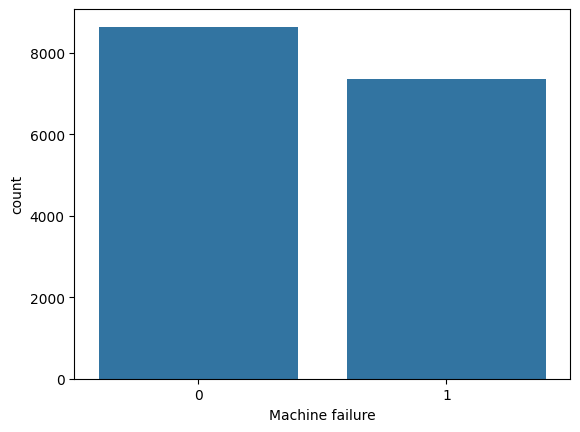

In [248]:
df["Machine failure"].value_counts()


sns.countplot(x="Machine failure", data=df)
plt.show()

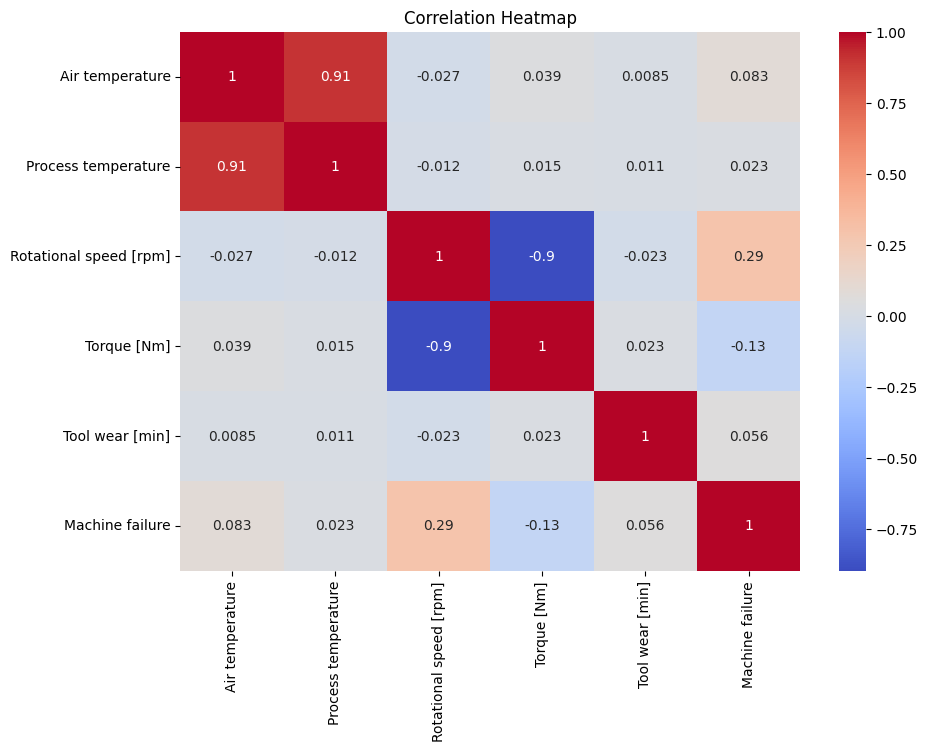

In [249]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# **PreProcessing**

In [250]:
numeric_cols = [
    "Air temperature",
    "Process temperature",
    "Rotational speed [rpm]"
]

imputer = SimpleImputer(strategy="median")

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [251]:
df["Type"] = df["Type"].fillna(df["Type"].mode()[0])

In [252]:
df.isnull().sum()

,0
date,0
device,0
Product ID,0
Type,0
Air temperature,0
Process temperature,0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0


# **Split Into** X & y

In [253]:
X = df.drop("Machine failure", axis=1)

y = df["Machine failure"]


X = X.drop(
    ["date", "Product ID", "device"],
    axis=1
)


X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True,
    dtype=int
)


X.head()

,Air temperature,Process temperature,Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,23.15,34.05,1637.0,31.6,27,1,0
1,29.25,37.05,1503.0,36.2,166,1,0
2,27.75,37.65,1490.0,38.1,125,1,0
3,25.85,36.35,1861.0,23.3,73,1,0
4,23.95,34.75,1609.0,38.9,166,0,1


# **Train Test Split**

In [254]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.1, random_state=42, stratify=y)

# **Scaling**

In [255]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Models**

**LogisticRegression**

In [256]:
model = LogisticRegression()

model.fit( X_train, y_train)

LogisticRegression()

In [257]:
y_pred = model.predict(X_test)

In [258]:
accuracy = accuracy_score( y_test, y_pred )

print("Accuracy:", accuracy)
print("\nClassification Report:")
print( classification_report( y_test, y_pred ))

Accuracy: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       864
           1       0.72      0.60      0.66       736

    accuracy                           0.71      1600
   macro avg       0.71      0.70      0.70      1600
weighted avg       0.71      0.71      0.71      1600



 **RandomForest**

In [259]:
rf = RandomForestClassifier( n_estimators=300 )
rf.fit( X_train, y_train)

RandomForestClassifier(n_estimators=300)

In [260]:
y_pred_rf = rf.predict(X_test)

print( "Accuracy:", accuracy_score( y_test, y_pred_rf))
print("\nClassification Report:")
print( classification_report( y_test, y_pred_rf ))

Accuracy: 0.918125

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       864
           1       0.90      0.92      0.91       736

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



**DecisionTree**

In [261]:
dt = DecisionTreeClassifier()
dt.fit( X_train, y_train )

DecisionTreeClassifier()

In [262]:
y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print( "Accuracy:", accuracy_score( y_test, y_pred_dt ))
print( classification_report( y_test, y_pred_dt ))

Decision Tree
Accuracy: 0.865625
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       864
           1       0.85      0.87      0.86       736

    accuracy                           0.87      1600
   macro avg       0.86      0.87      0.86      1600
weighted avg       0.87      0.87      0.87      1600



**SVM**


In [263]:
svm = SVC()
svm.fit( X_train, y_train)

SVC()

In [264]:
y_pred_svm = svm.predict(X_test)

print("SVM")
print( "Accuracy:", accuracy_score( y_test, y_pred_svm ))
print(classification_report( y_test, y_pred_svm ))

SVM
Accuracy: 0.878125
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       864
           1       0.86      0.88      0.87       736

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600



**KNN**


In [265]:
knn = KNeighborsClassifier( n_neighbors=3 )
knn.fit( X_train, y_train )

KNeighborsClassifier(n_neighbors=3)

In [266]:
y_pred_knn = knn.predict(X_test)

print("KNN")
print( "Accuracy:", accuracy_score( y_test, y_pred_knn ))
print( classification_report( y_test, y_pred_knn ))

KNN
Accuracy: 0.895625
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       864
           1       0.86      0.92      0.89       736

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



**XGBoost**

In [267]:
xgb = XGBClassifier()
xgb.fit( X_train, y_train )

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [268]:
y_pred_xgb = xgb.predict(X_test)

print( "XGBoost Accuracy:", accuracy_score( y_test, y_pred_xgb ))
print( classification_report( y_test, y_pred_xgb ))

XGBoost Accuracy: 0.94875
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       864
           1       0.94      0.95      0.94       736

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



**AdaBoost**

In [269]:
ada = AdaBoostClassifier()
ada.fit( X_train, y_train )

AdaBoostClassifier()

In [270]:
y_pred_ada = ada.predict(X_test)

print( "AdaBoost Accuracy:", accuracy_score( y_test, y_pred_ada ))
print( classification_report( y_test, y_pred_ada ))

AdaBoost Accuracy: 0.83125
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       864
           1       0.84      0.78      0.81       736

    accuracy                           0.83      1600
   macro avg       0.83      0.83      0.83      1600
weighted avg       0.83      0.83      0.83      1600



# **UI**

In [271]:
import gradio as gr


def predict_machine(
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear,
    machine_type
):

    input_data = pd.DataFrame({

        "Air temperature": [
            air_temperature
        ],

        "Process temperature": [
            process_temperature
        ],

        "Rotational speed [rpm]": [
            rotational_speed
        ],

        "Torque [Nm]": [
            torque
        ],

        "Tool wear [min]": [
            tool_wear
        ],

        "Type_L": [
            1 if machine_type == "L" else 0
        ],

        "Type_M": [
            1 if machine_type == "M" else 0
        ]
    })


    # Same preprocessing used during training

    input_scaled = scaler.transform(
        input_data
    )


    # XGBoost prediction

    prediction = xgb.predict(
        input_scaled
    )[0]


    # Failure probability

    probability = xgb.predict_proba(
        input_scaled
    )[0][1]


    if prediction == 1:

        result = "🔴 MACHINE FAILURE RISK"

        message = (
            "⚠️ Maintenance is recommended."
        )

    else:

        result = "🟢 MACHINE OK"

        message = (
            "✅ The machine is operating normally."
        )


    return (

        f"{result}\n\n"

        f"Failure Probability : "
        f"{probability * 100:.2f}%\n\n"

        f"{message}"
    )


# =========================================================
# Custom CSS
# =========================================================

custom_css = """

.gradio-container {
    max-width: 1000px !important;
    margin: auto !important;
}

.title {
    text-align: center;
}

.subtitle {
    text-align: center;
    color: #6b7280;
}

.result-box textarea {
    text-align: center;
    font-size: 20px !important;
    font-weight: bold;
}

"""


# =========================================================
# Gradio Interface
# =========================================================

with gr.Blocks(
    theme=gr.themes.Soft(),
    css=custom_css
) as interface:


    # -----------------------------------------------------
    # Header
    # -----------------------------------------------------

    gr.Markdown(
        """
        # ⚙️ Machine Failure Prediction

        ### Predictive Maintenance System
        """,

        elem_classes="title"
    )


    gr.Markdown(
        """
        Enter the machine parameters to predict
        whether the machine is likely to fail.
        """,

        elem_classes="subtitle"
    )


    # -----------------------------------------------------
    # Temperature
    # -----------------------------------------------------

    gr.Markdown(
        "## 🌡️ Temperature"
    )


    with gr.Row():

        air_temperature = gr.Number(
            label="Air Temperature (°C)",
            value=26.95
        )


        process_temperature = gr.Number(
            label="Process Temperature (°C)",
            value=36.95
        )


    # -----------------------------------------------------
    # Machine Performance
    # -----------------------------------------------------

    gr.Markdown(
        "## ⚙️ Machine Performance"
    )


    with gr.Row():

        rotational_speed = gr.Number(
            label="Rotational Speed (RPM)",
            value=1503
        )


        torque = gr.Number(
            label="Torque (Nm)",
            value=40
        )


    # -----------------------------------------------------
    # Tool Wear + Machine Type
    # -----------------------------------------------------

    with gr.Row():

        tool_wear = gr.Slider(
            minimum=0,
            maximum=253,
            step=1,
            value=108,
            label="Tool Wear (min)"
        )


        machine_type = gr.Dropdown(
            choices=["L", "M", "H"],
            value="M",
            label="Machine Type"
        )


    # -----------------------------------------------------
    # Prediction Button
    # -----------------------------------------------------

    predict_button = gr.Button(
        "🔍 Predict Machine Status",
        variant="primary",
        size="lg"
    )


    # -----------------------------------------------------
    # Result
    # -----------------------------------------------------

    gr.Markdown(
        "## 📊 Prediction Result"
    )


    result = gr.Textbox(
        label="Machine Status",
        lines=5,
        interactive=False,
        elem_classes="result-box"
    )


    # -----------------------------------------------------
    # Button Action
    # -----------------------------------------------------

    predict_button.click(

        fn=predict_machine,

        inputs=[
            air_temperature,
            process_temperature,
            rotational_speed,
            torque,
            tool_wear,
            machine_type
        ],

        outputs=result
    )


# =========================================================
# Launch
# =========================================================

interface.launch()

/tmp/ipykernel_3308/426460101.py:127: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c4427b956f87ead581.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
